In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
import gurobipy as gp
from gurobipy import GRB

### RDC 생성

block 지정해서 생성

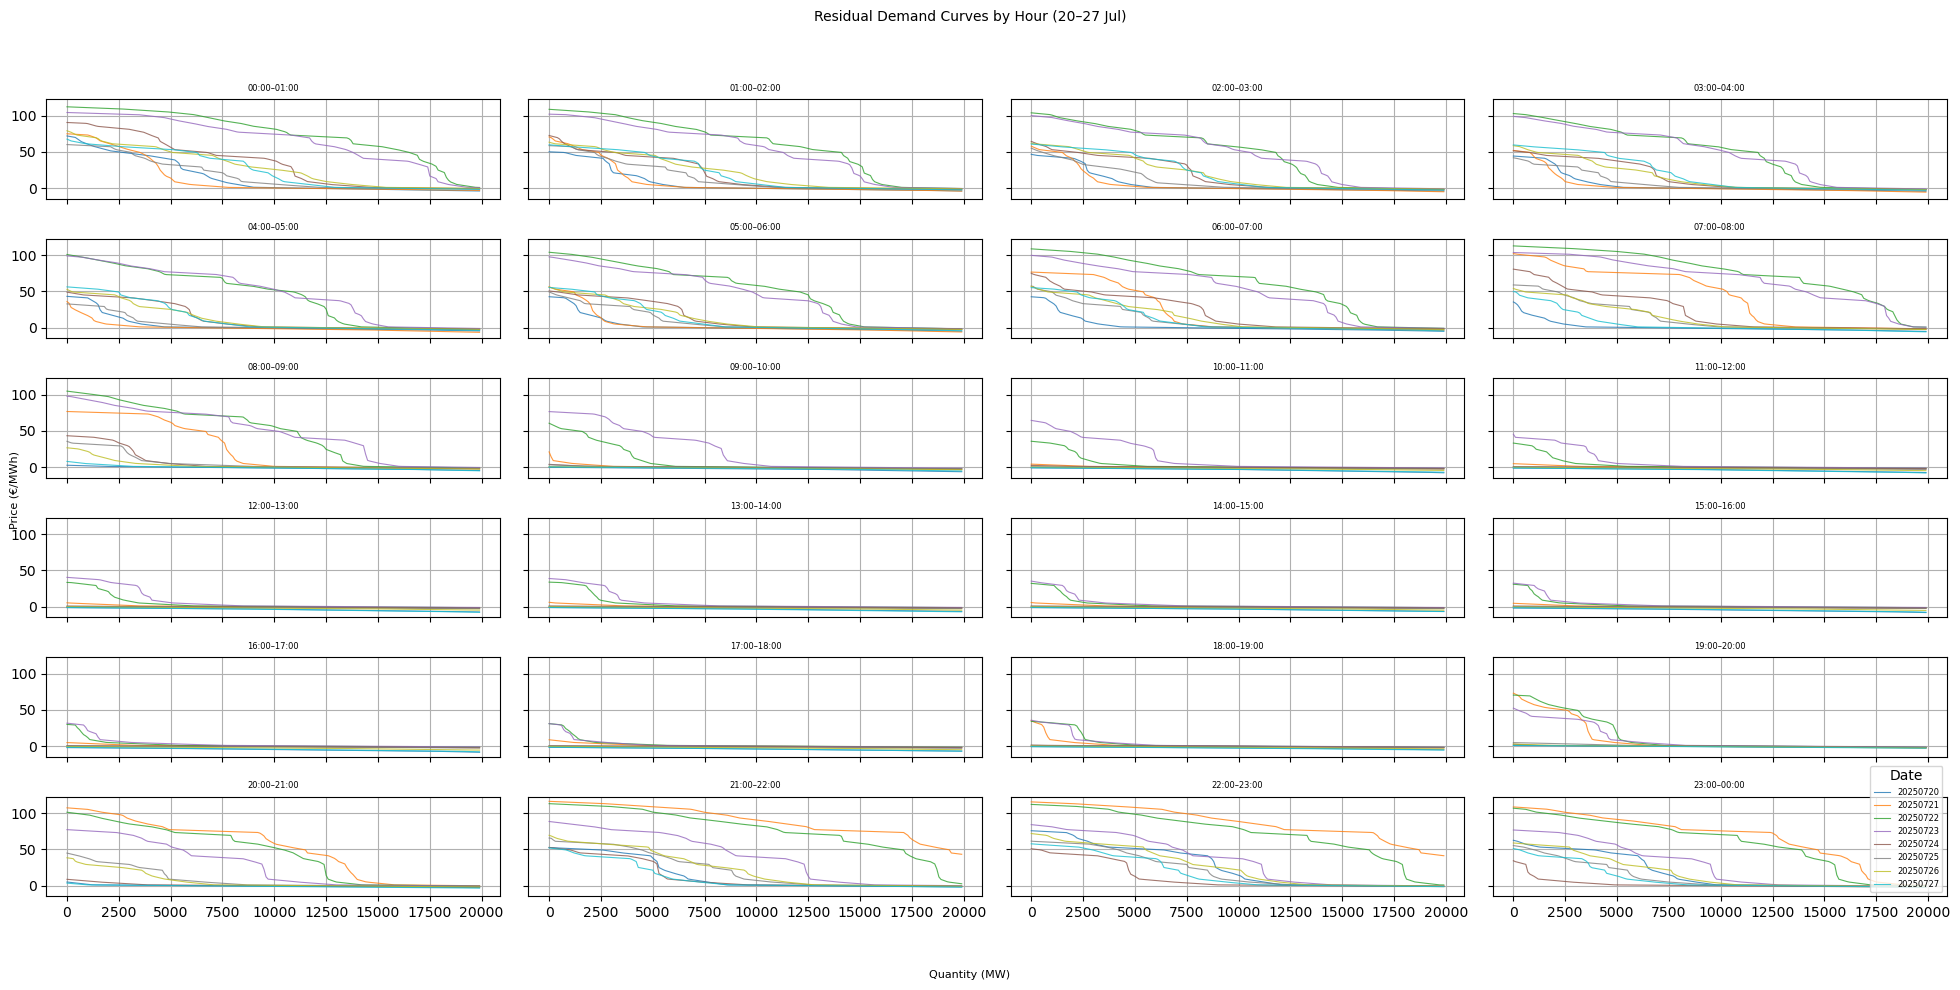

In [3]:
# --- A) RDC 계산 함수 (생략) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc

# --- B) 공통 설정 ---
days          = range(20,28)                 # 7/20~7/27
colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
# wf_offer_grid = np.arange(0,20001,100)       # 0,100,…,20000
# wf_offer_grid = np.arange(0, s_agg['Cumul'].max()*1.2, 100)

B             = 100                           # stepwise 블록 개수

# stepwise 파라미터 저장용
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

# --- C) 4×6 서브플롯 생성 (figsize 10×5) ---
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
                         sharex=True, sharey=True)
axes = axes.flatten()

# --- D) 각 Period(1~24) 에 대해 ---
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        # 이미 Price/Amount가 float 라고 가정
        sub    = df[df['Time Period']==period]
        sup    = sub[sub['GC']=='V']
        dem    = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 집계 & 누적
        # 집계 & 누적
        s_agg = sup.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        # 가격 낮을수록 누적이 커져야 하니 역순 누적
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단 보간
        s_f = interp1d(
            s_agg['Price'], s_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(0, s_agg['Cumul'].iat[-1])
        )
        d_f = interp1d(
            d_agg['Price'], d_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(d_agg['Cumul'].iat[0], 0)
        )

        pg  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
        sv  = s_f(pg)
        dv  = d_f(pg)
        #Original Clearing Price 계산
        def resid0(p): 
            return d_f(p) - s_f(p)   # q=0
        sol0 = root_scalar(resid0,
                           bracket=[pg[0], pg[-1]],
                           method='bisect')
        orig_cp[(date_str, period)] = sol0.root if sol0.converged else np.nan


        # wf_offer_grid = np.arange(
        #     0,
        #     s_agg['Cumul'].max() * 1.2,
        #     100
        # )

        wf_offer_grid = np.arange(
            0,
            20000,
            100
        )
        
        # Residual Demand
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)
        qv = np.array(qv); pv = np.array(pv)

        # ——— stepwise 근사 파라미터 계산 —————————
        q_breaks = np.linspace(0, qv.max(), B+1)
        delta_qs = q_breaks[1:] - q_breaks[:-1]
        for b in range(B):
            mid = 0.5*(q_breaks[b] + q_breaks[b+1])
            # date_str, period, block b 를 키로 사용
            qini   [(date_str, period, b)] = float(q_breaks[b])
            qmax   [(date_str, period, b)] = float(delta_qs[b])
            lambda_da_block[(date_str, period, b)] = float(np.interp(mid, qv, pv))
        # ————————————————————————————————

        # RDC Curve만 플롯
        # ax.plot(qv, pv, 'o-', color=color, label=date_str)
        ax.plot(
            qv, pv,
            '-',                # 실선만
            color=color,
            label=date_str,
            linewidth=0.8,
            alpha=0.8
        )

    # subplot 제목 (예: “00:00–01:00”)
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=6)
    ax.grid(True)

# --- E) 공통 레이블 & 레이아웃 ---
fig.supxlabel('Quantity (MW)', fontsize=8)
fig.supylabel('Price (€/MWh)', fontsize=8)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)

# 범례는 맨 마지막 축에만 표시하도록
axes[-1].legend(title='Date', fontsize=6, loc='lower right')

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


offer크기만큼 block 생성

C:\Users\symply_jina\AppData\Local\Temp\ipykernel_11944\3690748265.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend(title='Date', fontsize=8, loc='lower right')


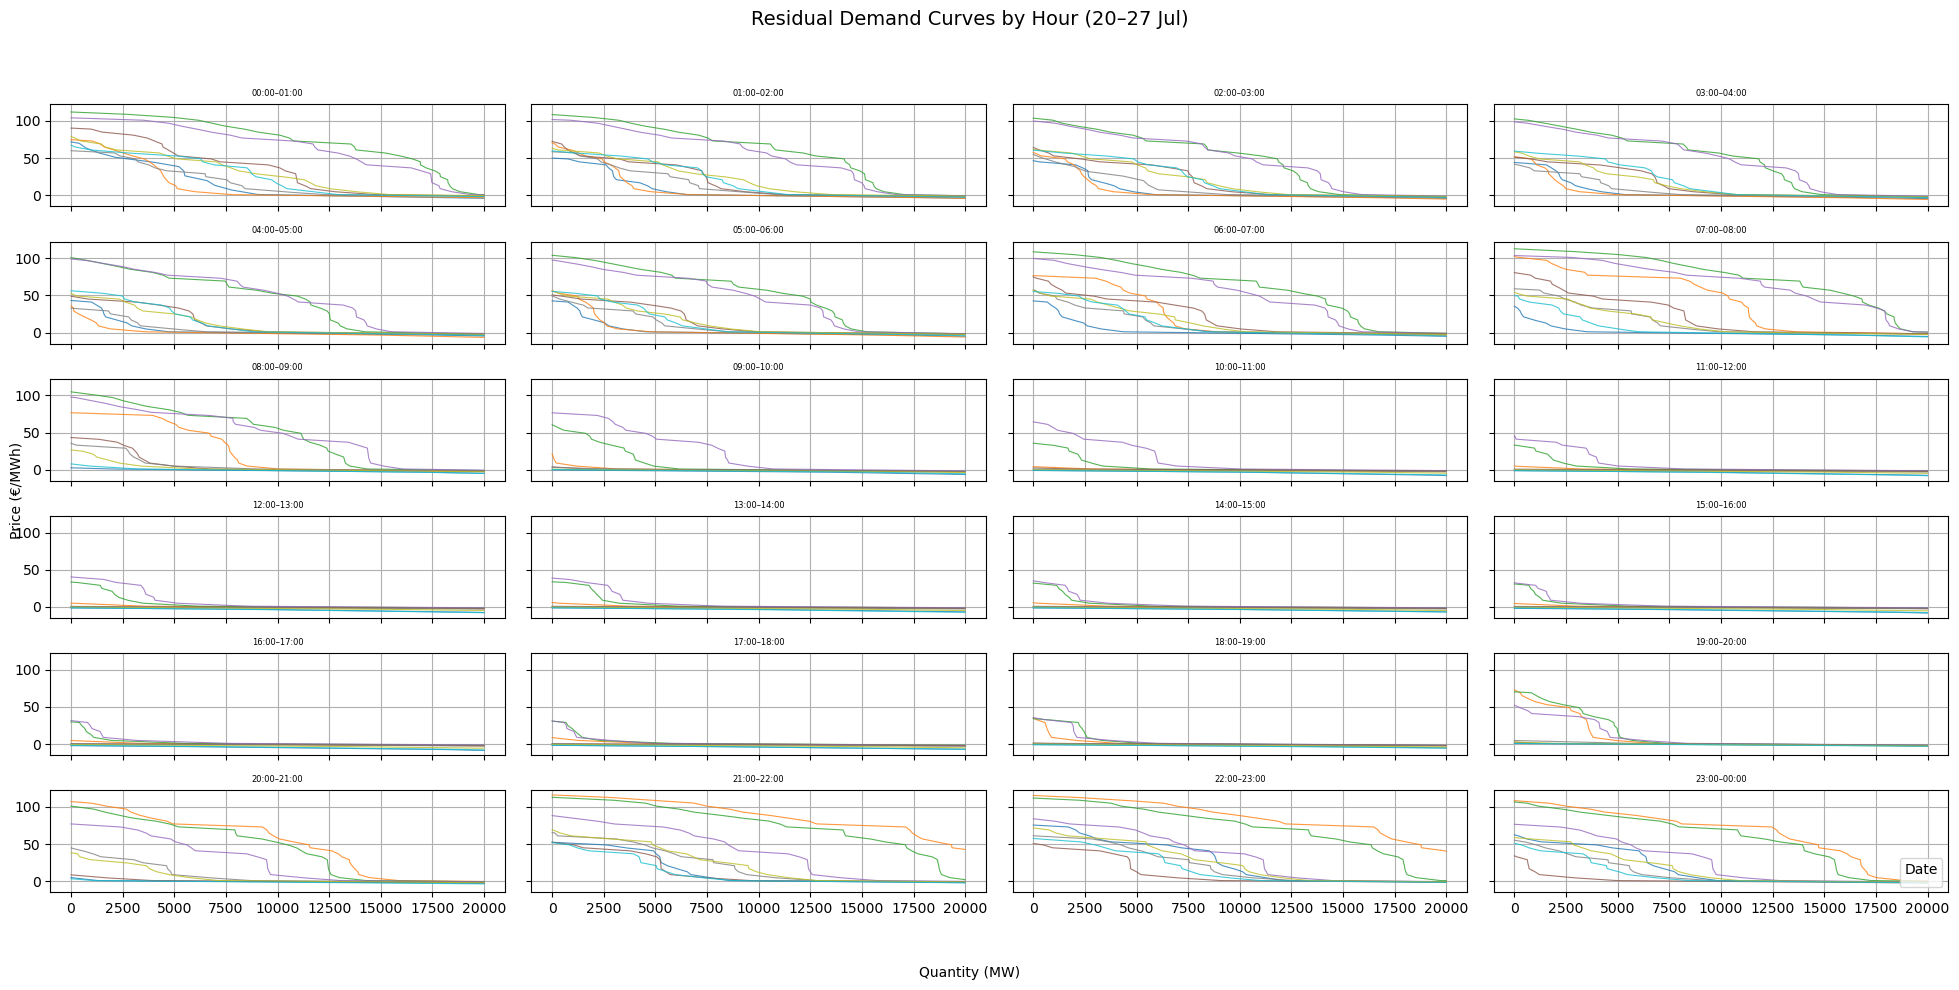

In [87]:
# ────────────────────────────────────────────────────
# A) 잔여수요 계산 함수 (선형보간)
# ────────────────────────────────────────────────────
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i],       resid[i+1]
            if r1 != r0:
                # 선형 보간으로 교차점 계산
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc

# ────────────────────────────────────────────────────
# B) 공통 설정
# ────────────────────────────────────────────────────
days   = range(20,28)  # 7/20~7/27
colors = plt.cm.tab10(np.linspace(0,1,len(days)))

# 결과 저장용 dict
qini            = {}   # (date, period, block) → block 시작 Q
qmax            = {}   # (date, period, block) → block 크기 ΔQ
lambda_da_block = {}   # (date, period, block) → DA 가격
orig_cp         = {}   # (date, period) → cleared price @ q=0

# ────────────────────────────────────────────────────
# C) 4×6 서브플롯 생성 (figsize=20×10)
# ────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
                         sharex=True, sharey=True)
axes = axes.flatten()

# ────────────────────────────────────────────────────
# D) 각 Period(1~24)에 대해
# ────────────────────────────────────────────────────
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        sub = df[df['Time Period']==period]
        sup = sub[sub['GC']=='V']
        dem = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 1) 공급/수요 집계 & 누적
        s_agg = (sup.groupby('Price')['Amount']
                    .sum().reset_index()
                    .sort_values('Price'))
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = (dem.groupby('Price')['Amount']
                    .sum().reset_index()
                    .sort_values('Price'))
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 2) 계단형 보간 함수
        s_f = interp1d(s_agg['Price'], s_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(0, s_agg['Cumul'].iat[-1]))
        d_f = interp1d(d_agg['Price'], d_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(d_agg['Cumul'].iat[0], 0))

        # 3) price grid 위에서 누적량 계산
        pg = np.linspace(s_agg['Price'].min(),
                         d_agg['Price'].max(), 500)
        sv = s_f(pg)
        dv = d_f(pg)

        # 4) q=0 일 때의 original clearing price
        def resid0(p): return d_f(p) - s_f(p)
        sol0 = root_scalar(resid0,
                           bracket=[pg[0], pg[-1]],
                           method='bisect')
        orig_cp[(date_str,period)] = sol0.root if sol0.converged else np.nan

        # 5) 100 MW 스텝별 WF‐offer 그리드 정의
        # wf_offer_grid = np.arange(0, s_agg['Cumul'].max() * 1.2, 100)
        wf_offer_grid = np.arange(0, 20000, 5) 

        # 6) Residual Demand Curve 계산
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)
        qv = np.array(qv); pv = np.array(pv)

        # 7) “블록”을 WF‐offer 스텝 그대로 정의
        q_breaks = wf_offer_grid
        delta_qs = np.diff(wf_offer_grid)   # 모두 100
        for b, (q0, dq) in enumerate(zip(q_breaks[:-1], delta_qs)):
            mid = q0 + dq/2
            qini   [(date_str,period,b)] = float(q0)
            qmax   [(date_str,period,b)] = float(dq)
            lambda_da_block[(date_str,period,b)] = float(
                np.interp(mid, qv, pv)
            )

        # 8) RDC 플롯
        ax.plot(qv, pv,
                '-', color=color,
                linewidth=0.8, alpha=0.8)

    # subplot 제목 설정
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=6)
    ax.grid(True)

# ────────────────────────────────────────────────────
# E) 공통 레이아웃
# ────────────────────────────────────────────────────
fig.supxlabel('Quantity (MW)', fontsize=10)
fig.supylabel('Price (€/MWh)', fontsize=10)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=14)
axes[-1].legend(title='Date', fontsize=8, loc='lower right')

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


In [88]:
delta_qs

array([5, 5, 5, ..., 5, 5, 5])

In [79]:
records = [
    {"date": d, "period": t, "orig_cp": orig_cp[(d,t)]}
    for d in [f"202507{day:02d}" for day in days]
    for t in range(1,25)
]
df_orig = pd.DataFrame(records)
print(df_orig)

         date  period  orig_cp
0    20250720       1    74.90
1    20250720       2    50.22
2    20250720       3    45.48
3    20250720       4    44.98
4    20250720       5    44.07
..        ...     ...      ...
187  20250727      20     1.00
188  20250727      21     3.60
189  20250727      22    51.00
190  20250727      23    58.20
191  20250727      24    51.00

[192 rows x 3 columns]


### Model 1.1

In [18]:
# 7월 20일만 뽑아낼 date_sel 정의
date_sel = "20250720"

# 해당 날짜 파라미터 필터링
qini20 = { (t,b): q for (d,t,b), q in qini.items()             if d==date_sel }
qmax20 = { (t,b): Δ for (d,t,b), Δ in qmax.items()            if d==date_sel }
lam20  = { (t,b): π for (d,t,b), π in lambda_da_block.items() if d==date_sel }

In [19]:
# 모델 파라미터 및 시나리오 생성

# 시간, 시나리오, 풍력 설비 인덱스
T = list(range(1,25))  # 24시간
J = [1,2,3,4]            # 15분 구간 4개
S = list(range(10))   # 10개 시나리오
I = [0]   # 1개 풍력 설비

# ESS 파라미터
eta_c, eta_d = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_q_max, pd_q_max = 500, 500     # 15분 단위 최대 충·방전
bigM = 1e4


# 풍력 발전량 시나리오 pwf[i,t,s]
np.random.seed(0)
Cw = 1000
pwf = {
    (i,t,s): max(0, np.random.normal(Cw*0.85, Cw*0.20))
    for i in I for t in T for s in S
}

#7월 20일 기준
rt_price_15min = [
    75.78, 75.54, 72.72, 42.23, 75.30, 75.30, 61.91, 35.25, 75.30, 48.33,
    39.81, 23.08, 65.80, 49.92, 33.81, 18.07, 45.68, 35.81, 26.04, 30.98,
    32.11, 36.47, 34.14, 29.49, 27.58, 34.34, 21.44, 33.44, 26.00,  3.30,
    -1.99, -8.99, 28.79,  0.49, -5.51, -6.31,  3.52,  0.65, -1.01, -5.90,
    -0.97, -3.00, -3.00,  0.00,  0.01,  4.31,  0.00,  0.00,  0.99,  0.99,
     0.14,  0.00,  0.65,  0.65,  0.65,  0.00,  0.99,  0.00,  0.00,  0.00,
    -0.65, -0.65, -0.50, -0.65,  0.00,  0.00,  0.00, -0.01, -0.61,  0.00,
     0.00,  0.00,  0.00,  0.00,  0.00,  0.00, -9.70, -0.97, 20.33, 79.89,
    -8.99,  8.81, 49.88, 83.87, 36.84, 66.60, 72.19, 75.54, 82.80, 82.80,
    85.21, 82.01, 86.16, 78.72, 72.27, 53.31
]
rt_price_15min = 0.5 * np.array(rt_price_15min)  # 15분 단위 RT 가격
# 1) 15분 가격을 (24시간 × 4구간) 배열로 재형성
rt15 = np.array(rt_price_15min).reshape(24, 4)  # shape=(24,4)

# 2) 인덱스 정의
T = list(range(1, 25))   # 1~24시
J = [1,2,3,4]            # 4구간
S = list(range(10))      # 10개 시나리오

# 3) 시나리오별 RT 가격 생성
np.random.seed(0)
sigma_eta = 0.1

# λ_rt_act[(t,j,s)] : 시나리오 s의 시간 t, 구간 j 실시간 가격
lambda_rt_act = {
    (t, j, s): rt15[t-1, j-1] * (1 + sigma_eta * np.random.randn())
    for t in T for j in J for s in S
}

# 4) 편차 delta_rt[(t,j,s)] 계산 (예: LDR에 쓸 경우)
#    편차는 15분 단위별 “실제 시나리오 가격 − 기준 평균 가격”
#    여기서 기준 평균 가격은 같은 시간·구간의 원래 rt15 값
delta_rt = {
    (t, j, s): lambda_rt_act[(t,j,s)] - rt15[t-1, j-1]
    for t in T for j in J for s in S
}

# 시나리오 확률
rho = {s: 1/len(S) for s in S}

In [ ]:
# # Convert pwf to DataFrame for i=0
# pwf_df = pd.DataFrame(
#     {s: [pwf[(0, t, s)] for t in T] for s in S},
#     index=T
# )
# pwf_df.index.name = 'Hour'

# # Convert lambda_rt_act and delta_rt to DataFrames
# lambda_df = pd.DataFrame(
#     {s: [lambda_rt_act[(t, s)] for t in T] for s in S},
#     index=T
# )
# lambda_df.index.name = 'Hour'

# delta_df = pd.DataFrame(
#     {s: [delta_rt[(t, s)] for t in T] for s in S},
#     index=T
# )
# delta_df.index.name = 'Hour'

# # Plot wind power scenarios
# plt.figure(figsize=(5, 3))
# for s in pwf_df.columns:
#     plt.plot(pwf_df.index, pwf_df[s], label=f"Scenario {s}")
# plt.title("Wind Power Scenarios (i=0)")
# plt.xlabel("Hour")
# plt.ylabel("Wind Power Output")
# plt.legend()
# plt.grid(True)
# plt.show()

# # Plot RT price scenarios
# plt.figure(figsize=(5, 3))
# for s in lambda_df.columns:
#     plt.plot(lambda_df.index, lambda_df[s], label=f"Scenario {s}")
# plt.title("Real-Time Price Scenarios (λ_rt_act)")
# plt.xlabel("Hour")
# plt.ylabel("Price")
# plt.legend()
# plt.grid(True)
# plt.show()


KeyError: (1, 0)

In [ ]:
# pwf_forecast = {
#     t: np.mean([ pwf[(0,t,s)] for s in S ])
#     for t in T
# }

# model = gp.Model("WF_ESS_PriceMaker")

# # 결정 변수
# # Day-Ahead 변수
# u    = model.addVars(
#     [(t,b) for t in T for b in valid_blocks[t]],
#     vtype=GRB.BINARY, name="u"
# )
# qvar = model.addVars(
#     [(t,b) for t in T for b in valid_blocks[t]],
#     lb=0.0, name="qvar"
# )

# # LDR 변수: nominal & slope for DA & RT errors
# pc0      = model.addVars(T, lb=0.0, ub=pc_max, name="pc0")
# pd0      = model.addVars(T, lb=0.0, ub=pd_max, name="pd0")
# # Dpc_da   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpc_da")
# Dpc_rt   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpc_rt")
# # Dpd_da   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpd_da")
# Dpd_rt   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpd_rt")

# #  Recourse 변수
# pc = model.addVars(T, S, lb=0.0, ub=pc_max, name="pc")
# pd = model.addVars(T, S, lb=0.0, ub=pd_max, name="pd")
# E  = model.addVars(T, S, lb=E_min, ub=E_max, name="E")

# # Binary for charge/discharge
# u_c = model.addVars(T, vtype=GRB.BINARY, name="u_c")
# u_d = model.addVars(T, vtype=GRB.BINARY, name="u_d")

# # 목적함수
# day_ahead = gp.quicksum(
#         lam20[(t,b)] * (u[t,b]*qini20[(t,b)] + qvar[t,b])
#         for t in T for b in valid_blocks[t]) #1e

# balancing = gp.quicksum(
#     rho[s] * lambda_rt_act[(t,s)] * (
#         sum(pwf[(i,t,s)] for i in I)
#       + pd[t,s]
#       - pc[t,s] #5d
#       - sum(u[t,b]*qini20[(t,b)] + qvar[t,b] for b in valid_blocks[t])  #1b, 1e
#     )
#     for t in T for s in S
# )
# model.setObjective(day_ahead + balancing, GRB.MAXIMIZE)
# # 제약식
# for t in T:
#     model.addConstr(
#         gp.quicksum(u[t,b]*qini20[(t,b)] + qvar[t,b]
#                     for b in valid_blocks[t])
#         <= pwf_forecast[t],
#         name=f"DA_commit_le_forecast_{t}"
#     ) #1o
    
# for t in T:
#     blks = valid_blocks[t]
#     # 1c: 하나의 블록만 선택
#     model.addConstr(
#         gp.quicksum(u[t,b] for b in blks) == 1,
#         name=f"one_block_{t}"
#     )
#     # 1d: qvar <= qmax * u
#     for b in blks:
#         model.addConstr(
#             qvar[t,b] <= qmax20[(t,b)] * u[t,b],
#             name=f"qvar_valid_{t}_{b}"
#         )
#     # 1k: charge/discharge binary
#     model.addConstr(u_c[t] + u_d[t] <= 1, name=f"no_simul_binary_{t}") #8b

#     for s in S:
#         # LDR affine
#         # 1h-1
#         model.addConstr(
#             pc[t,s] <= pc0[t]
#                       + Dpc_rt[t] * delta_rt[(t,s)],
#             name=f"LDR_pc_{t}_{s}"
#         )
#         #1i-1
#         model.addConstr(
#             pd[t,s] <= pd0[t]
#                       + Dpd_rt[t] * delta_rt[(t,s)], #7b ->10
#             name=f"LDR_pd_{t}_{s}"
#         )
#         # Big-M for pc/pd
        
#         model.addConstr(pc[t,s] <= pc_max * u_c[t],
#                         name=f"pc_bigm_{t}_{s}") #7a -> 9
#         model.addConstr(pd[t,s] <= pd_max * u_d[t],
#                         name=f"pd_bigm_{t}_{s}") #7b ->10
#         # SOC dynamics 7c
#         if t == 1: 
#             model.addConstr(
#                 E[t,s] == E0 + eta_c*pc[t,s] - pd[t,s]/eta_d,
#                 name=f"SOC_init_{t}_{s}"
#             )
#         else:
#             model.addConstr(
#                 E[t,s] == E[t-1,s] + eta_c*pc[t,s] - pd[t,s]/eta_d,
#                 name=f"SOC_trans_{t}_{s}"
#             )

# # time limit & optimize
# model.Params.TimeLimit = 60
# model.optimize()

In [ ]:
valid_blocks = {
    t: [ b 
         for (tt,b), dq in qmax20.items() 
         if tt == t and dq > 0 ]
    for t in T
}

In [21]:

model = gp.Model("WF_ESS_15min_LDR")

# ─────────────────────────────────────────────────────────────
# 1) 변수 선언
# 1.1) Day-Ahead (Here-and-Now)
u    = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    vtype=GRB.BINARY, name="u"
)
qvar = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    lb=0.0, name="qvar"
)

# 1.2) DA 총 커밋량 p_bid_t (Here-and-Now)
p_bid = model.addVars(
    T, lb=0.0, name="p_bid"
)

# 1.3) Recourse: LDR 계수와 절편
p_hat_c = model.addVars(
    [(t,j) for t in T for j in J],
    lb=0.0, name="p_hat_c"
)
p_hat_d = model.addVars(
    [(t,j) for t in T for j in J],
    lb=0.0, name="p_hat_d"
)
D_c = model.addVars(
    [(t,j) for t in T for j in J],
    lb=0.0, name="D_c"
)
D_d = model.addVars(
    [(t,j) for t in T for j in J],
    lb=0.0, name="D_d"
)

# 1.4) Recourse: 의사결정식에 따라 자동 결정되는 p_c, p_d
p_c = model.addVars(
    [(t,j,s) for t in T for j in J for s in S],
    lb=0.0, name="p_c"
)
p_d = model.addVars(
    [(t,j,s) for t in T for j in J for s in S],
    lb=0.0, name="p_d"
)

# 1.5) Recourse: SOC
E_q = model.addVars(
    [(t,j,s) for t in T for j in J for s in S],
    lb=E_min, ub=E_max, name="E_q"
)

# 1.6) Recourse: 실제 DA 잔량 p_b
p_b = model.addVars(
    [(t,j,s) for t in T for j in J for s in S],
    lb=0.0, name="p_b"
)

# 1.7) Recourse: 충·방전 모드
u_c = model.addVars(
    [(t,j) for t in T for j in J],
    vtype=GRB.BINARY, name="u_c"
)
u_d = model.addVars(
    [(t,j) for t in T for j in J],
    vtype=GRB.BINARY, name="u_d"
)

# ─────────────────────────────────────────────────────────────
# 2) 목적함수 (1a)
da_rev = gp.quicksum(
    lam20[(t,b)] * (u[t,b]*qini20[(t,b)] + qvar[t,b])
    for t in T for b in valid_blocks[t]
)
rt_rev = gp.quicksum(
    rho[s]
  * lambda_rt_act[(t, j, s)]   # 15분 구간별 price                     # 0.25h
  * (p_b[t,j,s]              # 시간 t, 시나리오 s 의 실제 잔량
      - (p_bid[t]/4)   # 시간 t 의 DA 약속량을 4등분
    )
  for s in S
    for t in T
    for j in J
)
model.setObjective(da_rev + rt_rev, GRB.MAXIMIZE)

# ─────────────────────────────────────────────────────────────
# 3) 제약식

# (1c,1d) 블록 선택 & qvar 한계
for t in T:
    model.addConstr(
        gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1,
        name=f"one_block_{t}"
    )
    for b in valid_blocks[t]:
        model.addConstr(
            qvar[t,b] <= qmax20[(t,b)] * u[t,b],
            name=f"qvar_max_{t}_{b}"
        )

# (1e) p_bid 정의
for t in T:
    model.addConstr(
        p_bid[t] == gp.quicksum(u[t,b]*qini20[(t,b)] + qvar[t,b]
                                for b in valid_blocks[t]),
        name=f"p_bid_def_{t}"
    )

# (1b) p_b 정의
for t in T:
    for j in J:
        for s in S:
            model.addConstr(
                p_b[t,j,s]
                == (sum(pwf[(i,t,s)] for i in I)/4)
                + p_d[t,j,s]
                - p_c[t,j,s],
                name=f"p_b_def_{t}_{j}_{s}"
            )

# (1g) DA vs RT 약속량 한계
for t in T:
    for s in S:
        model.addConstr(
            -gp.quicksum(p_c[t,j,s] for j in J) <= p_bid[t],
            name=f"bid_low_{t}_{s}"
        )
        model.addConstr(
            p_bid[t] <= sum(pwf[(i,t,s)] for i in I)
                        + gp.quicksum(p_d[t,j,s] for j in J),
            name=f"bid_up_{t}_{s}"
        )

# (1h,1i) LDR 결정규칙
for t in T:
    for j in J:
        for s in S:
            # charge
            model.addConstr(
                p_c[t,j,s] 
                == u_c[t,j]  # u_c=0 이면 p_c=0
                    * ( p_hat_c[t,j] 
                        + D_c[t,j] * delta_rt[(t,j,s)] ),
                name=f"LDR_pc_{t}_{j}_{s}"
            )
            # discharge
            model.addConstr(
                p_d[t,j,s] 
                == u_d[t,j] 
                    * ( p_hat_d[t,j] 
                        + D_d[t,j] * delta_rt[(t,j,s)] ),
                name=f"LDR_pd_{t}_{j}_{s}"
            )

# for t in T:
#     for j in J:
#         for s in S:
#             model.addConstr(
#                 p_c[t,j,s]
#                   == u_c[t,j] * D_c[t,j] * lambda_rt_act[(t,j,s)]
#                      + p_hat_c[t,j],
#                 name=f"LDR_pc_{t}_{j}_{s}"
#             )
#             model.addConstr(
#                 p_d[t,j,s]
#                   == u_d[t,j] * D_d[t,j] * lambda_rt_act[(t,j,s)]
#                      + p_hat_d[t,j],
#                 name=f"LDR_pd_{t}_{j}_{s}"
#             )

# (1k) 충·방전 동시 금지
for t in T:
    for j in J:
        model.addConstr(
            u_c[t,j] + u_d[t,j] <= 1,
            name=f"no_simul_{t}_{j}"
        )

# (1j) SOC 동적 전이
for s in S:
    for t in T:
        for j in J:
            if j == 1:
                prev = E0 if t == 1 else E_q[t-1, 4, s]
            else:
                prev = E_q[t, j-1, s]
            model.addConstr(
                E_q[t,j,s]
                  == prev
                     + 0.25*(eta_c*p_c[t,j,s] - p_d[t,j,s]/eta_d),
                name=f"SOC_{t}_{j}_{s}"
            )

# (1l,1m) 구간별 aggregate 한계
for t in T:
    for j in J:
        for s in S:
            agg_c = gp.quicksum(
                D_c[k,j] * lambda_rt_act[(k,j,s)] for k in T
            ) + p_hat_c[t,j]
            model.addConstr(
                p_c[t,j,s] <= agg_c,
                name=f"agg_c_ub_{t}_{j}_{s}"
            )
            agg_d = gp.quicksum(
                D_d[k,j] * lambda_rt_act[(k,j,s)] for k in T
            ) + p_hat_d[t,j]
            model.addConstr(
                p_d[t,j,s] <= agg_d,
                name=f"agg_d_ub_{t}_{j}_{s}"
            )

# (1n) SOC 경계는 변수 선언 시 적용됨

# ─────────────────────────────────────────────────────────────
# 4) 최적화
model.Params.TimeLimit = 60
model.optimize()


Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 6864 rows, 9240 columns and 62582 nonzeros
Model fingerprint: 0xe378ce4a
Model has 1920 quadratic constraints
Variable types: 6648 continuous, 2592 integer (2592 binary)
Coefficient statistics:
  Matrix range     [4e-03, 2e+04]
  QMatrix range    [3e-05, 1e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [2e-05, 3e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 2625 rows and 4617 columns
Presolve time: 0.05s
Presolved: 6531 rows, 5667 columns, 58284 nonzeros
Presolved model has 696 SOS constraint(s)
Variable types: 3831 continuous, 1836 integer (1825 binary)
Found heuristic solution: objective 313909.42683

Root relaxation: objective 1.01

In [22]:
# model = gp.Model("WF_ESS_PriceMaker")
# #──────────────────────
# # 5-1) Day-Ahead 결정변수 (Here-and-Now)
# u    = model.addVars(
#     [(t,b) for t in T for b in valid_blocks[t]],
#     vtype=GRB.BINARY, name="u"
# )
# qvar = model.addVars(
#     [(t,b) for t in T for b in valid_blocks[t]],
#     lb=0.0, name="qvar"
# )
# #  (c) DA 총 commitment
# p_bid = model.addVars(
#     T,
#     lb=0.0,
#     name="p_bid"      # p_bid[t]  (no scenario index)
# )


# # 2) Recourse 결정변수: LDR 계수와 절편
# # 2.1) 절편(ˆp)
# p_hat_c = model.addVars(
#     [(t,j) for t in T for j in J],
#     lb=0.0, name="p_hat_c"
# )
# p_hat_d = model.addVars(
#     [(t,j) for t in T for j in J],
#     lb=0.0, name="p_hat_d"
# )
# # 2.2) 기울기(D)
# D_c = model.addVars(
#     [(t,j) for t in T for j in J],
#     name="D_c"
# )
# D_d = model.addVars(
#     [(t,j) for t in T for j in J],
#     name="D_d"
# )

# # 2.3) 자동 결정되는 Recourse 변수
# p_c = model.addVars(
#     [(t,j,s) for t in T for j in J for s in S],
#     name="p_c"
# )
# p_d = model.addVars(
#     [(t,j,s) for t in T for j in J for s in S],
#     name="p_d"
# )
# E_q = model.addVars(
#     [(t,j,s) for t in T for j in J for s in S],
#     lb=E_min, ub=E_max, name="E_q"
# )
# p_b = model.addVars(
#     [(t,s) for t in T for s in S],
#     lb=0.0, name="p_b"
# )

# # ─────────────────────────────────────────────────────────────
# # 5-3) 목적함수 구성
# da_revenue = gp.quicksum(
#     lam20[(t,b)]
#   * (u[t,b]*qini20[(t,b)] + qvar[t,b])
#   for t in T for b in valid_blocks[t]
# )

# rt_revenue = gp.quicksum(
#     rho[s]
#   * lambda_rt_act[(t,j,s)]
#   * 0.25
#   * (
#         sum(pwf[(i,t,s)] for i in I)
#       + p_d[t,j,s]
#       - p_c[t,j,s]
#       - p_bid[t]        # <-- no scenario index
#     )
#     for s in S for t in T for j in J
# )

# model.setObjective(da_revenue + rt_revenue, GRB.MAXIMIZE)

# # ─────────────────────────────────────────────────────────────
# # 5-4) 제약식

# # 4.1) DA 블록 선택 & qvar (2c,2d)
# for t in T:
#     model.addConstr(sum(u[t,b] for b in valid_blocks[t]) == 1,
#                     name=f"one_block_{t}")
#     for b in valid_blocks[t]:
#         model.addConstr(qvar[t,b] <= qmax20[(t,b)] * u[t,b],
#                         name=f"qvar_max_{t}_{b}")

# # 4.2) p^bid 정의 (2e)
# for t in T:
#     model.addConstr(
#         p_bid[t] == gp.quicksum(u[t,b]*qini20[(t,b)] + qvar[t,b]
#                                 for b in valid_blocks[t]),
#         name=f"p_bid_def_{t}"
#     )

# # 4.3) p^b 정의 (2b)
# for t in T:
#     for s in S:
#         model.addConstr(
#             p_b[t,s]
#            == sum(pwf[(i,t,s)] for i in I)
#             + sum(p_d[t,j,s] for j in J)
#             - sum(p_c[t,j,s] for j in J),
#             name=f"p_b_def_{t}_{s}"
#         )

# # 4.4) DA vs RT 한계 (2g)
# for t in T:
#     for s in S:
#         model.addConstr(-sum(p_c[t,j,s] for j in J) <= p_bid[t],
#                         name=f"bid_low_{t}_{s}")
#         model.addConstr( p_bid[t] <= sum(pwf[(i,t,s)] for i in I)
#                          + sum(p_d[t,j,s] for j in J),
#                         name=f"bid_up_{t}_{s}")

# # 4.5) p_c, p_d LDR 정의 (2h,2i,2j,2k)
# for t in T:
#     for j in J:
#         for s in S:
#             # charge
#             model.addConstr(
#                 p_c[t,j,s] == p_hat_c[t,j]
#                               + D_c[t,j] * delta_rt[(t,j,s)],
#                 name=f"LDR_pc_{t}_{j}_{s}"
#             )
#             # discharge
#             model.addConstr(
#                 p_d[t,j,s] == p_hat_d[t,j]
#                               + D_d[t,j] * delta_rt[(t,j,s)],
#                 name=f"LDR_pd_{t}_{j}_{s}"
#             )

# # 4.6) SOC 동적 전이 (2l)
# for s in S:
#     for t in T:
#         for j in J:
#             if j==1:
#                 prev = E0 if t==1 else E_q[t-1,4,s]
#             else:
#                 prev = E_q[t,j-1,s]
#             model.addConstr(
#                 E_q[t,j,s] == prev
#                               + delta_rt[t,j,s]*(eta_c*p_c[t,j,s]
#                                     - p_d[t,j,s]/eta_d),
#                 name=f"SOC_{t}_{j}_{s}"
#             )
# # ─────────────────────────────────────────────────────────────
# # 6) 최적화
# model.Params.TimeLimit = 60
# model.optimize()

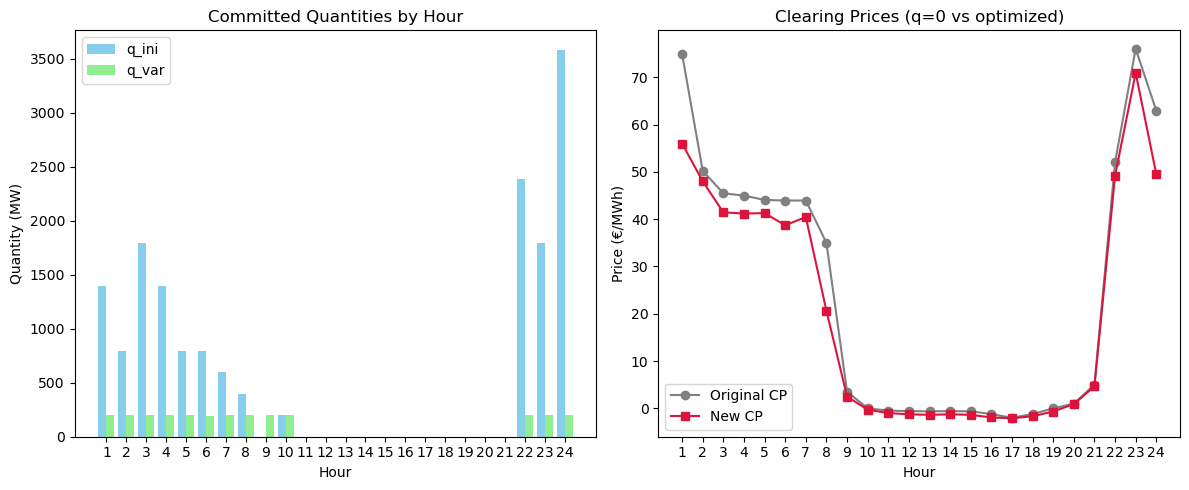

In [23]:
# --- 1) 최적화 완료 직후, 결과 추출 ---
hours      = T  # 1~24
q_ini_res  = []
q_var_res  = []
orig_price = []
new_price  = []
date_str = '20250720'  # 예시 날짜
for t in hours:
    # 선택된 block b 찾아서
    for b in valid_blocks[t]:
        if u[t,b].X > 0.5:
            q_ini_res.append(qini20[(t,b)])     # DA commit initial
            q_var_res.append(qvar[t,b].X)       # DA commit 추가량
            orig_price.append(orig_cp[(date_str, t)])  # q=0 clearing price
            new_price.append(lam20[(t,b)])      # 최적화된 DA price
            break

# --- 2) 시각화 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# 2-1) Committed Quantities by Hour
x = np.array(hours)
ax1.bar(x-0.2, q_ini_res, width=0.4, label='q_ini', color='skyblue')
ax1.bar(x+0.2, q_var_res, width=0.4, label='q_var', color='lightgreen')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Quantity (MW)')
ax1.set_title('Committed Quantities by Hour')
ax1.set_xticks(hours)
ax1.legend()

# 2-2) Clearing Prices 비교
ax2.plot(x, orig_price,    '-o', color='gray',   label='Original CP')
ax2.plot(x, new_price,     '-s', color='crimson', label='New CP')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Price (€/MWh)')
ax2.set_title('Clearing Prices (q=0 vs optimized)')
ax2.set_xticks(hours)
ax2.legend()

plt.tight_layout()
plt.show()


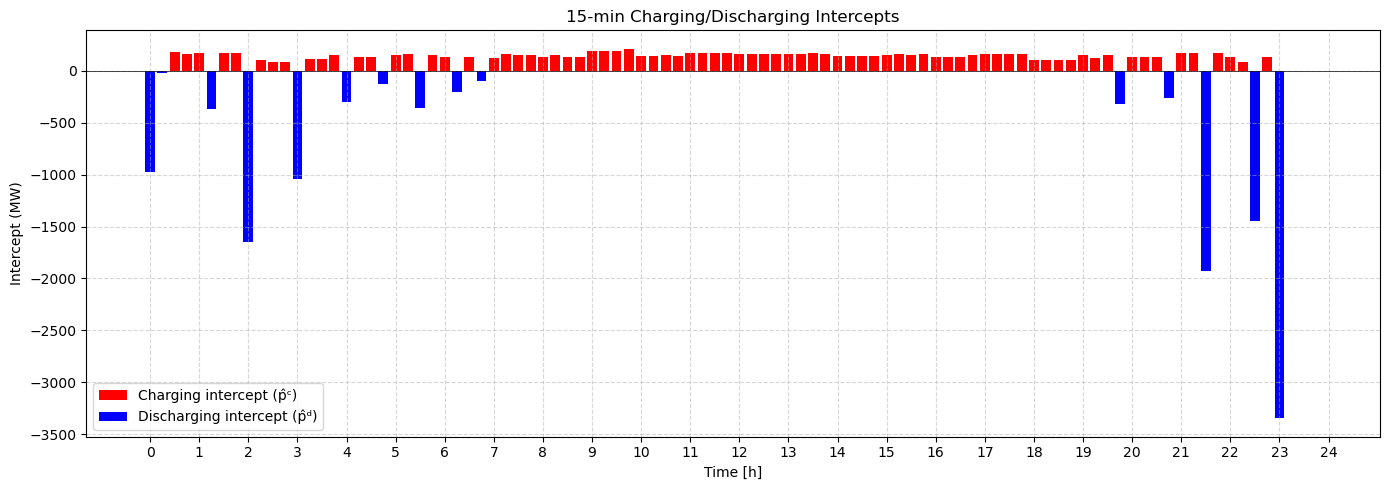

In [24]:
# T, J, p_hat_c, p_hat_d는 이미 메모리에 존재합니다
time_points  = [(t-1) + 0.25*(j-1) for t in T for j in J]
p_hat_c_flat = [p_hat_c[t,j].X for t in T for j in J]
p_hat_d_flat = [p_hat_d[t,j].X for t in T for j in J]

plt.figure(figsize=(14,5))
plt.bar(time_points, p_hat_c_flat, width=0.2, color='red',   label='Charging intercept (p̂ᶜ)')
plt.bar(time_points, [-v for v in p_hat_d_flat], width=0.2, color='blue', label='Discharging intercept (p̂ᵈ)')
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('Time [h]'); plt.ylabel('Intercept (MW)')
plt.title('15-min Charging/Discharging Intercepts')
plt.xticks(np.arange(0,24.1,1)); plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(); plt.tight_layout()
plt.show()

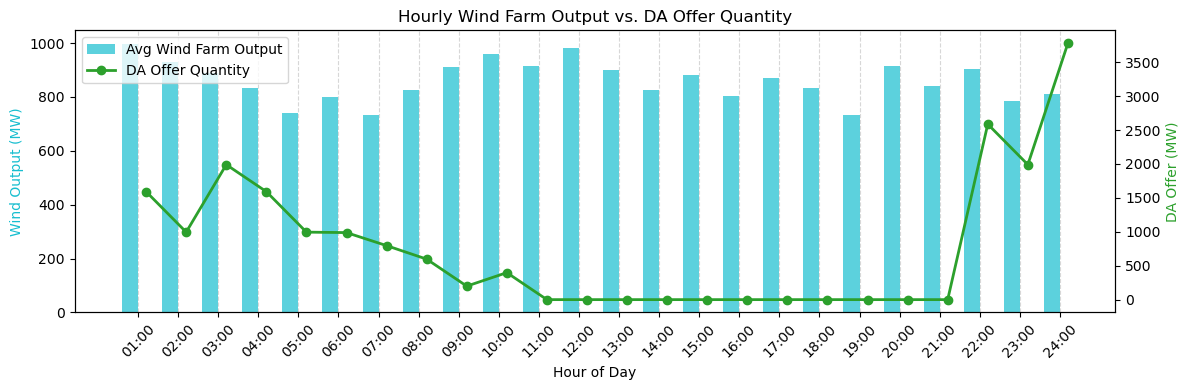

In [25]:
# ─────────────────────────────────────────────────────────────
# 1) 시간당 평균 풍력 발전량 계산
# ─────────────────────────────────────────────────────────────
# rho[s] 는 시나리오 확률, I = [0] 이므로 아래는 간단히 시나리오 평균만
pwf_bar = []
for t in T:
    # 시나리오별 풍력량을 확률로 가중합
    mean_wind = sum(rho[s]*pwf[(0,t,s)] for s in S)
    pwf_bar.append(mean_wind)

# ─────────────────────────────────────────────────────────────
# 2) DA 오퍼량 q_DA[t] 계산 (이미 구하셨다면 이 부분은 생략하셔도 됩니다)
# ─────────────────────────────────────────────────────────────
q_DA = []
for t in T:
    qt = sum(u[t,b].X * qini20[(t,b)] + qvar[t,b].X for b in range(B))
    q_DA.append(qt)

# ─────────────────────────────────────────────────────────────
# 3) 시각화: 풍력 vs. DA 오퍼량
# ─────────────────────────────────────────────────────────────
hours = np.array(T)
labels = [f"{h:02d}:00" for h in T]

fig, ax1 = plt.subplots(figsize=(12,4))
ax2 = ax1.twinx()

# 풍력(바)
ax1.bar(hours-0.2, pwf_bar, width=0.4, color='tab:cyan', alpha=0.7, label='Avg Wind Farm Output')
# DA 오퍼량(선)
ax2.plot(hours+0.2, q_DA, 'o-', color='tab:green', lw=2, label='DA Offer Quantity')

# 축 레이블 & 타이틀
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Wind Output (MW)", color='tab:cyan')
ax2.set_ylabel("DA Offer (MW)",   color='tab:green')
ax1.set_xticks(hours)
ax1.set_xticklabels(labels, rotation=45)
ax1.set_title("Hourly Wind Farm Output vs. DA Offer Quantity")

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')

ax1.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Model 2

In [26]:
# 1) 날짜 및 시나리오 정의
date_range = [f"202507{d:02d}" for d in range(20, 28)]  # 20,21,…,27
S = list(range(len(date_range)))                      # 시나리오 0~7
T = list(range(1, 25))                                # 시간 1~24
I = list(range(1))                                     # 풍력 설비 0번만
J = [1,2,3,4]                      # 15분 분할
Δt = 0.25

# 시나리오 확률 (균등)
rho = {s: 1/len(S) for s in S}

# 2) ESS 파라미터
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500

In [46]:
# 2) RDC 시나리오 파라미터 맵 생성
qini_scen       = {}
qmax_scen       = {}
lambda_da_scen  = {}

for s, date in enumerate(date_range):
    # qini
    for (d,t,b), q in qini.items():
        if d == date:
            qini_scen[(s,t,b)] = q
    # qmax
    for (d,t,b), Δ in qmax.items():
        if d == date:
            qmax_scen[(s,t,b)] = Δ
    # lambda_da
    for (d,t,b), π in lambda_da_block.items():
        if d == date:
            lambda_da_scen[(s,t,b)] = π

# ─────────────────────────────────────────────────────────────
# 3) valid_blocks 재생성: qmax_scen 에서 t별로 Δ>0 인 b만 남김
valid_blocks = {
    t: sorted({ b
                for (s2,t2,b),Δ in qmax_scen.items()
                if t2==t and Δ>0 })
    for t in T
}

In [47]:
# 기존에 (s, t, b) 순서로 되어 있던 시나리오 맵을 (t, b, s) 순서로 뒤집어 재생성
qini_scen      = { (t,b,s): qini_scen[(s,t,b)]       for (s,t,b)   in qini_scen      }
qmax_scen      = { (t,b,s): qmax_scen[(s,t,b)]       for (s,t,b)   in qmax_scen      }
lambda_da_scen = { (t,b,s): lambda_da_scen[(s,t,b)]  for (s,t,b)   in lambda_da_scen }

# 예시로 확인해보기 (pandas로 표 형태로)
import pandas as pd

df = pd.DataFrame([
    {"t":t, "b":b, "s":s,
     "qini": q, 
     "qmax": qmax_scen[(t,b,s)],
     "lam_da": lambda_da_scen[(t,b,s)]}
    for (t,b,s), q in qini_scen.items()
])
display(df.sort_values(["t","b","s"]).head(10))


,t,b,s,qini,qmax,lam_da
0,1,0,0,0.0,199.0,71.420758
2400,1,0,1,0.0,199.0,74.716676
4800,1,0,2,0.0,199.0,111.938513
7200,1,0,3,0.0,199.0,104.107621
9600,1,0,4,0.0,199.0,90.302251
12000,1,0,5,0.0,199.0,59.877103
14400,1,0,6,0.0,199.0,78.036052
16800,1,0,7,0.0,199.0,66.211664
1,1,1,0,199.0,199.0,70.499776
2401,1,1,1,199.0,199.0,74.378941


In [29]:
# df_blocks = pd.DataFrame({
#     'Hour': T,
#     'Valid Blocks': [valid_blocks[t] for t in T]
# })
# print("=== Valid Blocks by Hour ===")
# print(df_blocks.to_string(index=False))

# # 2) Scenario 0 에 대한 qini, qmax, lambda_da (샘플)
# rows = []
# for (s,t,b), q in qini_scen.items():
#     if s == 0:
#         rows.append({
#             'Hour':      t,
#             'Block':     b,
#             'qini':      q,
#             'qmax':      qmax_scen[(s,t,b)],
#             'lambda_da': lambda_da_scen[(s,t,b)]
#         })
# df_s0 = pd.DataFrame(rows).sort_values(['Hour','Block'])
# print("\n=== Scenario 0: qini / qmax / lambda_da ===")
# print(df_s0.to_string(index=False))

In [30]:


# # A) ‘블록 개수’ 히스토그램: valid_blocks 길이
# counts = [len(valid_blocks[t]) for t in T]
# plt.figure(figsize=(10,3))
# plt.bar(T, counts)
# plt.xlabel('Hour'); plt.ylabel('Number of Valid Blocks')
# plt.title('Valid Blocks per Hour')
# plt.xticks(T)
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.show()

# # B) Scenario 0의 qini vs qmax 비교 (상위 5개 시간만 샘플)
# sample_hours = sorted(df_s0['Hour'].unique())[:5]
# for hour in sample_hours:
#     df_h = df_s0[df_s0['Hour']==hour]
#     plt.figure(figsize=(5,2))
#     plt.bar(df_h['Block']-0.2, df_h['qini'], width=0.4, label='qini')
#     plt.bar(df_h['Block']+0.2, df_h['qmax'], width=0.4, label='qmax')
#     plt.xlabel('Block'); plt.ylabel('Quantity')
#     plt.title(f'Scenario 0, Hour {hour}')
#     plt.legend()
#     plt.show()


In [31]:
# # ─── 기존 valid_blocks 대신 아래를 쓰세요 ───
# valid_blocks = {
#     t: sorted({
#         b
#         for s in S
#         for (s2,t2,b),dq in qmax_scen.items()
#         if s2==s and t2==t and dq>0
#     })
#     for t in T
# }


In [32]:
# # 1) 날짜 및 시나리오 정의
# date_range = [f"202507{d:02d}" for d in range(20, 28)]  # 20,21,…,27
# S = list(range(len(date_range)))                      # 시나리오 0~7
# T = list(range(1, 25))                                # 시간 1~24
# I = list(range(1))                                     # 풍력 설비 0번만
# J = [1,2,3,4]                      # 15분 분할
# Δt = 0.25

# # 시나리오 확률 (균등)
# rho = {s: 1/len(S) for s in S}

# # 2) ESS 파라미터
# eta_c, eta_d    = 0.9, 0.9
# E0, E_min, E_max = 1400, 500, 2250
# pc_max, pd_max  = 500, 500

# # 3) RDC 시나리오 생성: qini_scen[(s,t,b)], qmax_scen[(s,t,b)], lambda_da_scen[(s,t,b)]
# qini_scen = {
#     (s, t, b): qini[(date_range[s], t, b)]
#     for s in S for t in T for b in valid_blocks[t]
# }
# qmax_scen = {
#     (s, t, b): qmax[(date_range[s], t, b)]
#     for s in S for t in T for b in valid_blocks[t]
# }
# lambda_da_scen = {
#     (s, t, b): lambda_da_block[(date_range[s], t, b)]
#     for s in S for t in T for b in valid_blocks[t]
# }

In [33]:
# # 시나리오 확률 (균등)
# rho = {s: 1/len(S) for s in S}

# # 2) ESS 파라미터
# eta_c, eta_d    = 0.9, 0.9
# E0, E_min, E_max = 1400, 500, 2250
# pc_max, pd_max  = 500, 500

#7월 20일 기준
rt_price_15min = [
    75.78, 75.54, 72.72, 42.23, 75.30, 75.30, 61.91, 35.25, 75.30, 48.33,
    39.81, 23.08, 65.80, 49.92, 33.81, 18.07, 45.68, 35.81, 26.04, 30.98,
    32.11, 36.47, 34.14, 29.49, 27.58, 34.34, 21.44, 33.44, 26.00,  3.30,
    -1.99, -8.99, 28.79,  0.49, -5.51, -6.31,  3.52,  0.65, -1.01, -5.90,
    -0.97, -3.00, -3.00,  0.00,  0.01,  4.31,  0.00,  0.00,  0.99,  0.99,
     0.14,  0.00,  0.65,  0.65,  0.65,  0.00,  0.99,  0.00,  0.00,  0.00,
    -0.65, -0.65, -0.50, -0.65,  0.00,  0.00,  0.00, -0.01, -0.61,  0.00,
     0.00,  0.00,  0.00,  0.00,  0.00,  0.00, -9.70, -0.97, 20.33, 79.89,
    -8.99,  8.81, 49.88, 83.87, 36.84, 66.60, 72.19, 75.54, 82.80, 82.80,
    85.21, 82.01, 86.16, 78.72, 72.27, 53.31
]
rt_price_15min = 0.5 * np.array(rt_price_15min)  # 15분 단위 RT 가격
# 1) 15분 가격을 (24시간 × 4구간) 배열로 재형성
rt15_arr = np.array(rt_price_15min).reshape(24, 4)

# (t,j) → price 사전 생성
#  t=1..24,  j=1..4
lambda_rt = {
    (t, j): float(rt15_arr[t-1, j-1])
    for t in T for j in J
}

block 선택 및 q_var을 시나리오별로

In [34]:

# 풍력 예측 & RT 가격 (Deterministic)
pwf_forecast = {t: np.mean([pwf[(0,t,s)] for s in S]) for t in T}
# lambda_rt[(t,j)] 는 15분 단위 RT clearing price를 이미 준비했다고 가정

# ─── 2) 모델 생성 ──────────────────────────────────────────
model = gp.Model("RDC_Scenarios_Single_ESS")

# 2.1) RDC 시나리오 변수
u_rc    = model.addVars([(t,b,s) for t in T for b in valid_blocks[t] for s in S],
                        vtype=GRB.BINARY, name="u_rc")
qvar_rc = model.addVars([(t,b,s) for t in T for b in valid_blocks[t] for s in S],
                        lb=0.0, name="qvar_rc")
p_bid   = model.addVars([(t,s) for t in T for s in S],
                        lb=0.0, name="p_bid")
p_b     = model.addVars([(t,s) for t in T for s in S],
                        lb=0.0, name="p_b")

# 2.2) ESS here-and-now 변수
u_c = model.addVars([(t,j) for t in T for j in J],
                    vtype=GRB.BINARY, name="u_c")
u_d = model.addVars([(t,j) for t in T for j in J],
                    vtype=GRB.BINARY, name="u_d")
p_c = model.addVars([(t,j) for t in T for j in J],
                    lb=0.0, ub=pc_max, name="p_c")
p_d = model.addVars([(t,j) for t in T for j in J],
                    lb=0.0, ub=pd_max, name="p_d")
E_q = model.addVars([(t,j) for t in T for j in J],
                    lb=E_min, ub=E_max, name="E_q")

# ─── 3) 목적함수 (1a) ───────────────────────────────────────
da_rev = gp.quicksum(
    rho[s]
  * lambda_da_scen[(s,t,b)]
  * (u_rc[t,b,s]*qini_scen[(s,t,b)] + qvar_rc[t,b,s])
  for s in S for t in T for b in valid_blocks[t]
)
rt_rev = gp.quicksum(
    rho[s]
  * lambda_rt[(t,j)]
  * Δt
  * (
        pwf_forecast[t]
      + p_d[t,j]
      - p_c[t,j]
      - p_b[t,s]
    )
  for s in S for t in T for j in J
)
model.setObjective(da_rev + rt_rev, GRB.MAXIMIZE)

# ─── 4) 제약식 ───────────────────────────────────────────────
# 4.1) RDC: 블록 선택 & qvar 한계 (1c,1d)
for t in T:
    for s in S:
        model.addConstr(
            gp.quicksum(u_rc[t,b,s] for b in valid_blocks[t]) == 1,
            name=f"one_rc_{t}_{s}"
        )
        for b in valid_blocks[t]:
            model.addConstr(
                qvar_rc[t,b,s] <= qmax_scen[(s,t,b)] * u_rc[t,b,s],
                name=f"qvar_rc_{t}_{b}_{s}"
            )

# 4.2) RDC: p_bid 정의 (1e)
for t in T:
    for s in S:
        model.addConstr(
            p_bid[t,s] == gp.quicksum(
                u_rc[t,b,s]*qini_scen[(s,t,b)]
              + qvar_rc[t,b,s]
                for b in valid_blocks[t]
            ), name=f"p_bid_def_{t}_{s}"
        )

# 4.3) RDC: p_b 정의 (1b)
for t in T:
    for s in S:
        model.addConstr(
            p_b[t,s] == pwf_forecast[t]
                     + gp.quicksum(p_d[t,j] for j in J)
                     - gp.quicksum(p_c[t,j] for j in J),
            name=f"p_b_def_{t}_{s}"
        )

# 4.4) DA vs RT 약속량 한계 (1g)
for t in T:
    for s in S:
        model.addConstr(
            -gp.quicksum(p_c[t,j] for j in J) <= p_bid[t,s],
            name=f"bid_low_{t}_{s}"
        )
        model.addConstr(
            p_bid[t,s] <= pwf_forecast[t]
                         + gp.quicksum(p_d[t,j] for j in J),
            name=f"bid_up_{t}_{s}"
        )

# 4.5) ESS: 충·방전 동시 금지 & big-M (1k)
for t in T:
    for j in J:
        model.addConstr(u_c[t,j] + u_d[t,j] <= 1,
                        name=f"no_sim_{t}_{j}")
        model.addConstr(p_c[t,j] <= pc_max * u_c[t,j],
                        name=f"pc_bigm_{t}_{j}")
        model.addConstr(p_d[t,j] <= pd_max * u_d[t,j],
                        name=f"pd_bigm_{t}_{j}")

# 4.6) ESS: SOC 동적 전이 (1j)
for t in T:
    for j in J:
        prev = E0 if (t==1 and j==1) else (
            E_q[t-1,4] if j==1 else E_q[t,j-1]
        )
        model.addConstr(
            E_q[t,j] == prev
                       + Δt*(eta_c*p_c[t,j] - p_d[t,j]/eta_d),
            name=f"SOC_{t}_{j}"
        )

# 4.7) SOC 경계 (1n) 은 이미 변수에 적용됨

# ─── 5) 최적화 ───────────────────────────────────────────────
model.Params.TimeLimit = 60
model.optimize()

KeyError: (0, 1, 0)

q_var만 시나리오별로

In [48]:

# ESS 파라미터
eta_c, eta_d = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_q_max, pd_q_max = 500, 500     # 15분 단위 최대 충·방전
bigM = 1e4


# 풍력 발전량 시나리오 pwf[i,t,s]
np.random.seed(0)
Cw = 1000
pwf = {
    (i,t,s): max(0, np.random.normal(Cw*0.85, Cw*0.20))
    for i in I for t in T for s in S
}

#7월 20일 기준
rt_price_15min = [
    75.78, 75.54, 72.72, 42.23, 75.30, 75.30, 61.91, 35.25, 75.30, 48.33,
    39.81, 23.08, 65.80, 49.92, 33.81, 18.07, 45.68, 35.81, 26.04, 30.98,
    32.11, 36.47, 34.14, 29.49, 27.58, 34.34, 21.44, 33.44, 26.00,  3.30,
    -1.99, -8.99, 28.79,  0.49, -5.51, -6.31,  3.52,  0.65, -1.01, -5.90,
    -0.97, -3.00, -3.00,  0.00,  0.01,  4.31,  0.00,  0.00,  0.99,  0.99,
     0.14,  0.00,  0.65,  0.65,  0.65,  0.00,  0.99,  0.00,  0.00,  0.00,
    -0.65, -0.65, -0.50, -0.65,  0.00,  0.00,  0.00, -0.01, -0.61,  0.00,
     0.00,  0.00,  0.00,  0.00,  0.00,  0.00, -9.70, -0.97, 20.33, 79.89,
    -8.99,  8.81, 49.88, 83.87, 36.84, 66.60, 72.19, 75.54, 82.80, 82.80,
    85.21, 82.01, 86.16, 78.72, 72.27, 53.31
]
rt_price_15min = 0.5 * np.array(rt_price_15min)  # 15분 단위 RT 가격
# 1) 15분 가격을 (24시간 × 4구간) 배열로 재형성
rt15 = np.array(rt_price_15min).reshape(24, 4)  # shape=(24,4)

# 2) 인덱스 정의
T = list(range(1, 25))   # 1~24시
J = [1,2,3,4]            # 4구간
S = list(range(10))      # 10개 시나리오

# 3) 시나리오별 RT 가격 생성
np.random.seed(0)
sigma_eta = 0.1

# λ_rt_act[(t,j,s)] : 시나리오 s의 시간 t, 구간 j 실시간 가격
lambda_rt_act = {
    (t, j, s): rt15[t-1, j-1] * (1 + sigma_eta * np.random.randn())
    for t in T for j in J for s in S
}

# 4) 편차 delta_rt[(t,j,s)] 계산 (예: LDR에 쓸 경우)
#    편차는 15분 단위별 “실제 시나리오 가격 − 기준 평균 가격”
#    여기서 기준 평균 가격은 같은 시간·구간의 원래 rt15 값
delta_rt = {
    (t, j, s): lambda_rt_act[(t,j,s)] - rt15[t-1, j-1]
    for t in T for j in J for s in S
}

# 시나리오 확률
rho = {s: 1/len(S) for s in S}

In [49]:
# 풍력 발전량 시나리오 pwf[i,t,s]
np.random.seed(0)
Cw = 1000
pwf = {
    (i,t,s): max(0, np.random.normal(Cw*0.85, Cw*0.20))
    for i in I for t in T for s in S
}
# 풍력 예측 & RT 가격 (Deterministic)
pwf_forecast = {
    (i, t): np.mean([ pwf[(i, t, s)] for s in S ])
    for i in I for t in T
}

In [37]:
I = [0]   # 1개 풍력 설비


In [51]:
# ─── 2) 모델 생성 ──────────────────────────────────────────
model = gp.Model("RDC_Scenarios_Single_ESS")

# 2.1) RDC 시나리오 변수
u      = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    vtype=GRB.BINARY, name="u"
)
# “추가 수량”은 시나리오별 recourse 결정변수로 변경
qvar   = model.addVars(
    [(t,b,s) for t in T for b in valid_blocks[t] for s in S],
    lb=0.0, name="qvar"
)
p_bid   = model.addVars([(t,s) for t in T for s in S],
                        lb=0.0, name="p_bid")

p_hat_c = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# 2.2) ESS here-and-now 변수
u_c = model.addVars([(t,j) for t in T for j in J],
                    vtype=GRB.BINARY, name="u_c")
u_d = model.addVars([(t,j) for t in T for j in J],
                    vtype=GRB.BINARY, name="u_d")


p_c = model.addVars([(t,j) for t in T for j in J],
                    lb=0.0, ub=pc_max, name="p_c")
p_d = model.addVars([(t,j) for t in T for j in J],
                    lb=0.0, ub=pd_max, name="p_d")
E_q = model.addVars([(t,j) for t in T for j in J],
                    lb=E_min, ub=E_max, name="E_q")
p_b   = model.addVars( [(t,j) for t in T for j in J] ,lb=0.0, name="p_b")

#  2) 목적함수
da_rev = gp.quicksum(
    rho[s]
  * lambda_da_scen[(t,b,s)]
  * (u[t,b]*qini_scen[(t,b,s)] + qvar[t,b,s])
  for s in S for t in T for b in valid_blocks[t]
)

rt_rev = gp.quicksum(
    rho[s]
  * lambda_rt[(t, j)]   # 15분 구간별 price                     # 0.25h
  * (p_b[t,j]              # 시간 t, 시나리오 s 의 실제 잔량
      - (p_bid[t,s]/4)   # 시간 t 의 DA 약속량을 4등분
    )
  for s in S
    for t in T
    for j in J
)

# rt_rev = gp.quicksum(
#     rho[s]
#   * lambda_rt[(t,j)] * Δt
#   * (p_b[t] - p_bid[t,s]
#     )
#   for s in S for t in T
# )
model.setObjective(da_rev + rt_rev, GRB.MAXIMIZE)

# ─── 4) 제약식 ───────────────────────────────────────────────
# 3.1) 블록 선택 (Here-and-Now)
for t in T:
    model.addConstr(
        gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1,
        name=f"one_block_{t}"
    )

# 3.2) qvar ≤ qmax * u  (Recourse)
for t in T:
    for b in valid_blocks[t]:
        for s in S:
            model.addConstr(
                qvar[t,b,s] <= qmax_scen[(t,b,s)] * u[t,b],
                name=f"qvar_max_{t}_{b}_{s}"
            )

# 3.3) p_bid 정의
for t in T:
    for s in S:
        model.addConstr(
            p_bid[t,s] == gp.quicksum(
                u[t,b]*qini_scen[(t,b,s)]
              + qvar[t,b,s]
                for b in valid_blocks[t]
            ), name=f"p_bid_def_{t}_{s}"
        )


# 4.3) RDC: p_b 정의 (1b)
for t in T:
    for j in J:
        model.addConstr(
            p_b[t,j]
            == (sum(pwf_forecast[(i,t)] for i in I)/4)
            + p_d[t,j]
            - p_c[t,j],
            name=f"p_b_def_{t}_{j}"
        )

# 4.4) DA vs RT 약속량 한계 (1g)
for t in T:
    for s in S:
        model.addConstr(
            -gp.quicksum(p_c[t,j] for j in J) <= p_bid[t,s],
            name=f"bid_low_{t}_{s}"
        )
        for i in I:
            model.addConstr(
                p_bid[t,s] <= pwf_forecast[i,t]
                            + gp.quicksum(p_d[t,j] for j in J),
                name=f"bid_up_{t}_{s}"
            )

# 4.5) ESS: 충·방전 동시 금지 & big-M (1k)
for t in T:
    for j in J:
        model.addConstr(u_c[t,j] + u_d[t,j] <= 1,
                        name=f"no_sim_{t}_{j}")
        model.addConstr(p_c[t,j] <= pc_max * u_c[t,j],
                        name=f"pc_bigm_{t}_{j}")
        model.addConstr(p_d[t,j] <= pd_max * u_d[t,j],
                        name=f"pd_bigm_{t}_{j}")

# 4.6) ESS: SOC 동적 전이 (1j)
for t in T:
    for j in J:
        prev = E0 if (t==1 and j==1) else (
            E_q[t-1,4] if j==1 else E_q[t,j-1]
        )
        model.addConstr(
            E_q[t,j] == prev
                       + Δt*(eta_c*p_c[t,j] - p_d[t,j]/eta_d),
            name=f"SOC_{t}_{j}"
        )

# 4.7) SOC 경계 (1n) 은 이미 변수에 적용됨

# ─── 5) 최적화 ───────────────────────────────────────────────
model.Params.TimeLimit = 60
model.optimize()

KeyError: (1, 0, 8)

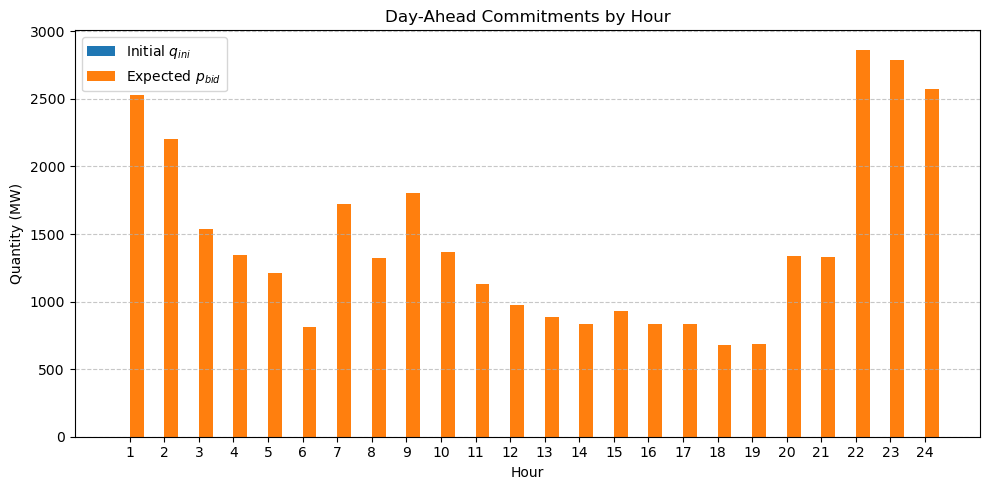

In [ ]:
# today = date_range[0]  # 첫 번째 날짜
today = date_range[0]

# — 1) 초기 약속량만 담은 dict 생성 —
qini_init = {}
for t in T:
    for b in valid_blocks[t]:
        # 없으면 0으로 처리
        qini_init[(t,b)] = qini.get((today, t, b), 0.0)

# — 2) 시간축 —
hours = T  # 1~24

# — 3) 시간별 기대 DA 약속량: 시나리오 가중평균 p_bid[t,s] —
p_bid_exp = []
for t in hours:
    val = sum(rho[s] * p_bid[t, s].X for s in S)
    p_bid_exp.append(val)

# — 4) 시간별 초기 q_ini (here-and-now) —
qini_exp = []
for t in hours:
    val = sum(u[t, b].X * qini_init[(t, b)] for b in valid_blocks[t])
    qini_exp.append(val)

# — 5) 시각화 —
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, len(hours) + 1)
width = 0.4

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, qini_exp, width, label='Initial $q_{ini}$')
plt.bar(x + width/2, p_bid_exp, width, label='Expected $p_{bid}$')

plt.xlabel('Hour')
plt.ylabel('Quantity (MW)')
plt.title('Day-Ahead Commitments by Hour')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


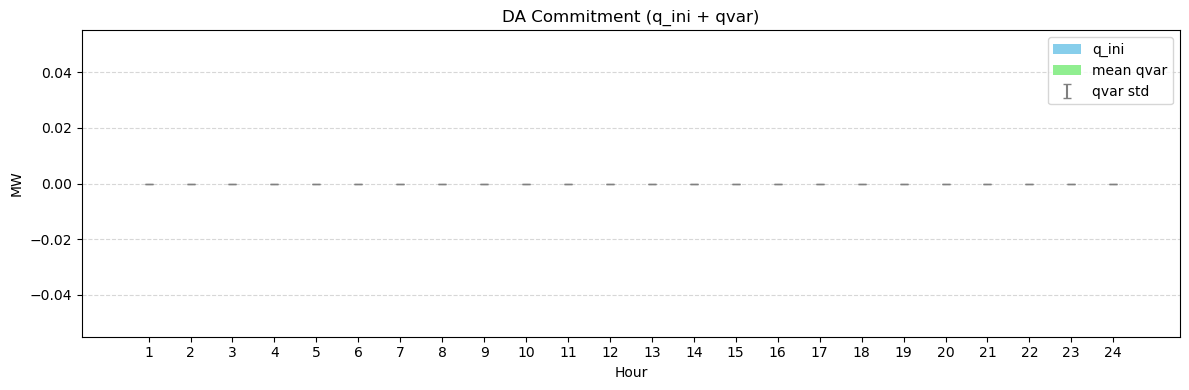

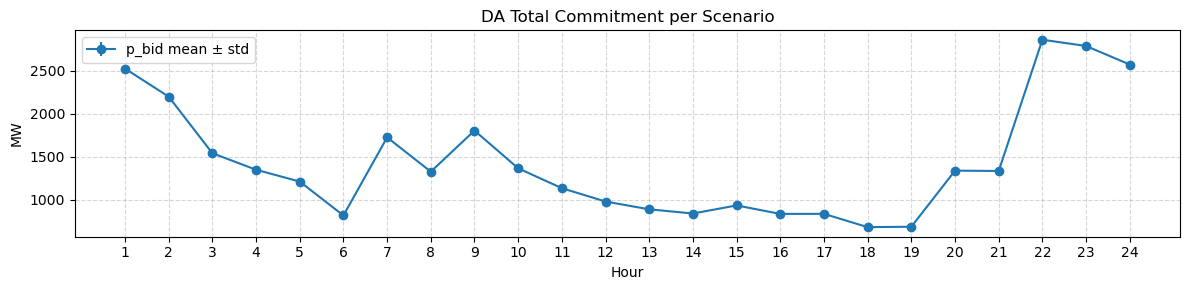

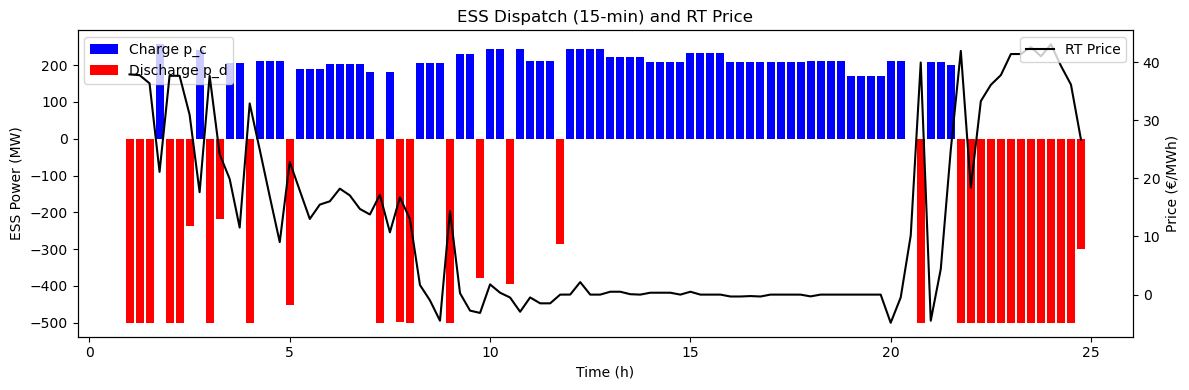

In [ ]:


# 1.1) valid_blocks 재생성 (qmax_scen 기반)
valid_blocks = {
    t: sorted({b for (s2,t2,b), Δ in qmax_scen.items() if t2 == t and Δ > 0})
    for t in T
}

# 1.2) Day-Ahead에서 선택된 블록 b_star (Here-and-Now 변수 u)
b_star = {}
for t in T:
    chosen = [b for b in valid_blocks[t] if u[t,b].X > 0.5]
    b_star[t] = chosen[0] if chosen else None

# 1.3) qini_base (모든 시나리오 동일한 초기 약속량)
qini_base = np.array([
    qini_scen[(0, t, b_star[t])] if b_star[t] is not None else 0
    for t in T
])

# 1.4) qvar 통계 (Recourse 변수 qvar[t,b,s]의 시나리오별 평균·표준편차)
mean_qvar = np.array([
    np.mean([qvar[t,b_star[t],s].X for s in S]) if b_star[t] is not None else 0
    for t in T
])
std_qvar = np.array([
    np.std([qvar[t,b_star[t],s].X for s in S]) if b_star[t] is not None else 0
    for t in T
])

# 1.5) 시나리오별 총 약속량 p_bid 통계
mean_pbid = np.array([
    np.mean([p_bid[t,s].X for s in S])
    for t in T
])
std_pbid = np.array([
    np.std([p_bid[t,s].X for s in S])
    for t in T
])

# 1.6) ESS 디스패치 (Here-and-Now 변수 p_c,p_d)
pc_flat = np.array([p_c[t,j].X for t in T for j in J])
pd_flat = np.array([p_d[t,j].X for t in T for j in J])
hours15 = [t + (j-1)*Δt for t in T for j in J]

# 1.7) 15분 단위 실시간 가격 (lambda_rt[(t,j)])
price15 = np.array([lambda_rt[(t,j)] for t in T for j in J])

# ────────────────────────────────────────────────────────────
# 2) 시각화

# A) Day-Ahead Commitment: q_ini + mean(qvar) ± std
plt.figure(figsize=(12,4))
x = np.arange(1, len(T)+1)
plt.bar(x, qini_base, label='q_ini', color='skyblue')
plt.bar(x, mean_qvar, bottom=qini_base, label='mean qvar', color='lightgreen')
plt.errorbar(x, qini_base+mean_qvar, yerr=std_qvar,
             fmt='none', ecolor='gray', capsize=3, label='qvar std')
plt.xticks(x); plt.xlabel('Hour'); plt.ylabel('MW')
plt.title('DA Commitment (q_ini + qvar)')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# B) 시나리오별 Total Bid (p_bid)
plt.figure(figsize=(12,3))
plt.errorbar(x, mean_pbid, yerr=std_pbid, fmt='-o', label='p_bid mean ± std')
plt.xticks(x); plt.xlabel('Hour'); plt.ylabel('MW')
plt.title('DA Total Commitment per Scenario')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# C) ESS Dispatch vs RT Price (15분 단위)
fig, ax1 = plt.subplots(figsize=(12,4))
ax1.bar(hours15, pc_flat, width=0.2, label='Charge p_c', color='blue')
ax1.bar(hours15, -pd_flat, width=0.2, label='Discharge p_d', color='red')
ax1.set_xlabel('Time (h)'); ax1.set_ylabel('ESS Power (MW)')
ax1.set_title('ESS Dispatch (15-min) and RT Price')
ax2 = ax1.twinx()
ax2.plot(hours15, price15, '-k', label='RT Price')
ax2.set_ylabel('Price (€/MWh)')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()
